## RTL-SDR-Samples im Notebook einlesen

→  |  [Interaktiver Spektralplot](rtl_sdr_spectrum_interactive.ipynb)  |  [Slider: Center/Gain](rtl_sdr_sliders.ipynb)

Mit **pyrtlsdr** kannst du im Jupyter-Notebook direkt Samples vom RTL-SDR-Stick lesen. Der Stick liefert **IQ-Samples** (komplexe Basisbandwerte).

**Hinweise:** RTL-SDR per USB verbinden; unter Windows ggf. **Zadig** (WinUSB/libusb) nutzen. Nur ein Prozess kann das Gerät gleichzeitig nutzen – nach dem Lesen das Gerät mit `sdr.close()` freigeben.

### Gerät öffnen, konfigurieren, Samples lesen

### Windows: Treiber-Pfad setzen (vor dem Import)

Das Skript `rtlsdr_spectrum_plot.py` hängt den Ordner **rtl-sdr-driver** (mit `librtlsdr.dll`) an `PATH` und `os.add_dll_directory()` an. Im Notebook fehlt das – daher die folgende Zelle **zuerst** ausführen. Sie sucht `rtl-sdr-driver` im aktuellen Verzeichnis oder in übergeordneten Ordnern (z. B. Repo-Root `KT-workspace`). Treiber liegt typisch in `C:\_Git\KT-workspace\rtl-sdr-driver`.

In [5]:
import os
from pathlib import Path

# Treiber rtl-sdr-driver (librtlsdr.dll) suchen: im CWD oder in übergeordneten Ordnern
# Typischer Ort: KT-workspace/rtl-sdr-driver (Repo-Root)
_driver_dir = None
for p in [Path.cwd()] + list(Path.cwd().parents):
    candidate = p / "rtl-sdr-driver"
    if candidate.exists() and (candidate / "librtlsdr.dll").exists():
        _driver_dir = candidate
        break
if _driver_dir is not None:
    _path = str(_driver_dir)
    os.environ["PATH"] = _path + os.pathsep + os.environ.get("PATH", "")
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_path)
    print("RTL-SDR Treiber gefunden:", _driver_dir)
else:
    print("Hinweis: Ordner 'rtl-sdr-driver' (mit librtlsdr.dll) nicht gefunden.",
          "Notebook aus KT-workspace oder lab_suite starten, oder Treiber dort ablegen.")

RTL-SDR Treiber gefunden: C:\Users\ralfk\GIT_KT\rtl-sdr-driver


In [6]:
from rtlsdr import RtlSdr
import numpy as np

sdr = RtlSdr()
sdr.sample_rate = 2.048e6   # Abtastrate in Hz
sdr.center_freq = 93e6    # Mittenfrequenz in Hz (z. B. 100 MHz)
sdr.gain = 20.0   # maximaler Gain (geräteabhängig)

num_samples = 4096
for i in range(10):
    samples = sdr.read_samples(num_samples)
samples = sdr.read_samples(num_samples)
sample_rate = sdr.sample_rate  # für Spektrum (FFT) in der Plot-Zelle
sdr.close()  # Gerät freigeben

print("Anzahl Samples:", len(samples))
print("Typ (komplex):", samples.dtype)
print("Erste 5 Werte:", samples[:5])

Anzahl Samples: 4096
Typ (komplex): complex128
Erste 5 Werte: [-0.01960784+0.00392157j  0.06666667-0.01176471j  0.02745098+0.03529412j
  0.01176471-0.00392157j  0.01176471-0.02745098j]


### Kurz erklärt

- **`RtlSdr()`** – öffnet das erste gefundene RTL-SDR-Gerät.
- **`sample_rate`** – Abtastrate (z. B. 2.048e6 = 2,048 MHz).
- **`center_freq`** – Mittenfrequenz in Hz.
- **`read_samples(n)`** – liefert **n** komplexe IQ-Samples als 1D-Array (dtype komplex).
- **`sdr.close()`** – unbedingt aufrufen, damit andere Programme (oder die nächste Zelle) den Stick nutzen können.

Ohne angeschlossenes Gerät führt `RtlSdr()` zu einer Fehlermeldung; die obige Zelle dient dann nur als Referenz.

### I/Q als Rohdaten (Integer) und Spektrum

Die komplexen Samples bestehen aus **I** (Realteil) und **Q** (Imaginärteil). Hier werden I und Q als **raw Integer** (8‑Bit-Bereich, aus den normalisierten Float-Werten) dargestellt. Anschließend werden das **zweiseitige Spektrum** (FFT-Betrag, $-f_s/2 \ldots +f_s/2$) der IQ-Samples sowie dasselbe Spektrum in **logarithmischer Amplitudendarstellung (dB-Skala)** geplottet – bei komplexen IQ-Daten sind negative und positive Frequenzen getrennt sichtbar.

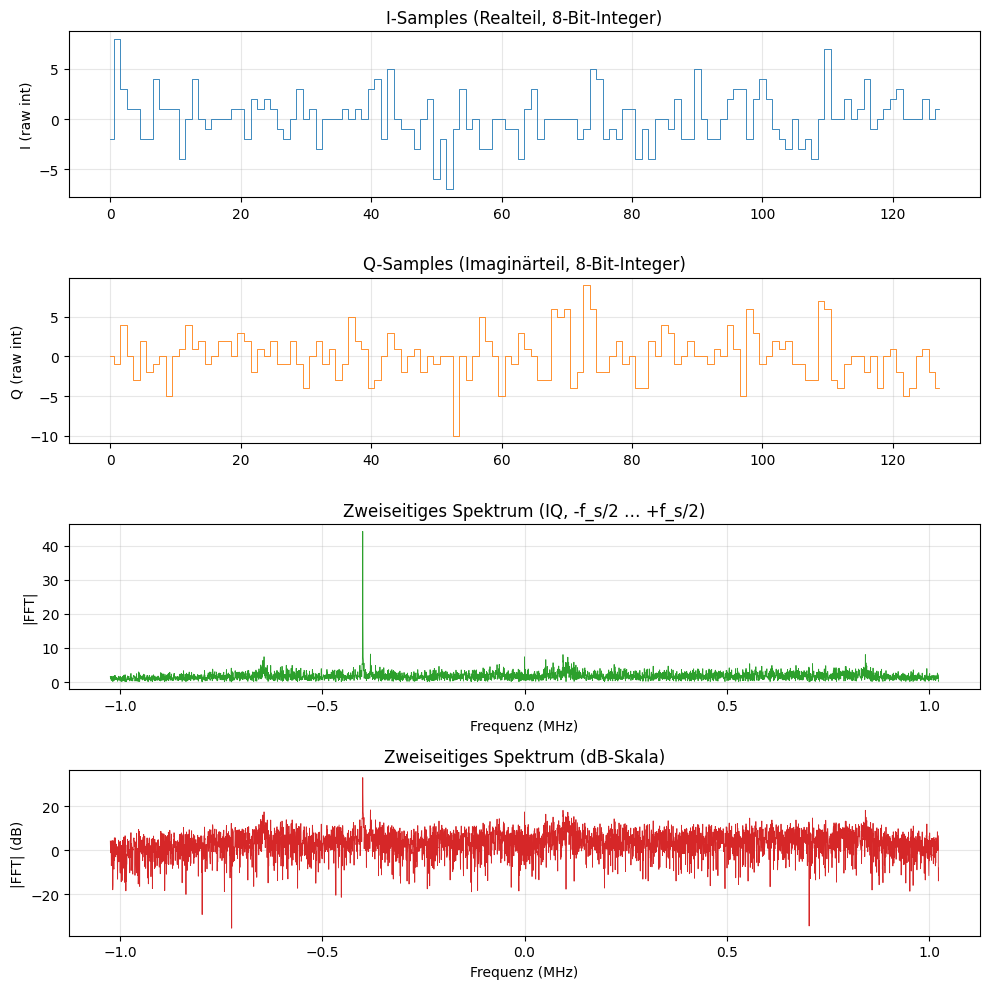

In [7]:
import matplotlib.pyplot as plt
import numpy as np

if 'samples' not in globals() or len(samples) == 0:
    print("Zuerst die Zelle mit read_samples() ausführen (und RTL-SDR angeschlossen).")
else:
    # I und Q aus komplexen Samples; als raw Integer (8-Bit-Bereich -128..127)
    I = np.real(samples)
    Q = np.imag(samples)
    # pyrtlsdr liefert oft normalisierte Floats -> Skalierung auf Integer
    I_int = np.clip(np.round(I * 127), -128, 127).astype(np.int32)
    Q_int = np.clip(np.round(Q * 127), -128, 127).astype(np.int32)

    fs = globals().get('sample_rate', 2.048e6)
    N = len(samples)

    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=False)

    # I (Realteil) als raw Integer
    axes[0].plot(I_int[:128], color='C0', linewidth=0.6, drawstyle='steps-mid')
    axes[0].set_ylabel('I (raw int)')
    axes[0].set_title('I-Samples (Realteil, 8-Bit-Integer)')
    axes[0].grid(True, alpha=0.3)

    # Q (Imaginärteil) als raw Integer
    axes[1].plot(Q_int[:128], color='C1', linewidth=0.6, drawstyle='steps-mid')
    axes[1].set_ylabel('Q (raw int)')
    axes[1].set_title('Q-Samples (Imaginärteil, 8-Bit-Integer)')
    axes[1].grid(True, alpha=0.3)

    # Zweiseitiges Spektrum (IQ-Samples: negative und positive Frequenzen)
    X = np.fft.fft(samples)
    freq = np.fft.fftfreq(N, 1 / fs)
    magnitude = np.abs(X)
    # Für Darstellung: 0 in der Mitte (-f_s/2 … +f_s/2)
    freq_shifted = np.fft.fftshift(freq)
    magnitude_shifted = np.fft.fftshift(magnitude)

    axes[2].plot(freq_shifted / 1e6, magnitude_shifted, color='C2', linewidth=0.6)
    axes[2].set_xlabel('Frequenz (MHz)')
    axes[2].set_ylabel('|FFT|')
    axes[2].set_title('Zweiseitiges Spektrum (IQ, -f_s/2 … +f_s/2)')
    axes[2].grid(True, alpha=0.3)

    # Zweiseitiges Spektrum mit logarithmischer Amplitudendarstellung (dB)
    magnitude_dB = 20 * np.log10(magnitude_shifted + 1e-12)  # +1e-12 gegen log(0)
    axes[3].plot(freq_shifted / 1e6, magnitude_dB, color='C3', linewidth=0.6)
    axes[3].set_xlabel('Frequenz (MHz)')
    axes[3].set_ylabel('|FFT| (dB)')
    axes[3].set_title('Zweiseitiges Spektrum (dB-Skala)')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

→  |  [Interaktiver Spektralplot](rtl_sdr_spectrum_interactive.ipynb)  |  [Slider: Center/Gain](rtl_sdr_sliders.ipynb)